In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('pendulumData.csv')

In [58]:
data.head()

,label,g (m/s2),stat uncert,sys uncert,total uncert
0,20.Sep.X.B01.01,9.830,0.0075,"""+0.35,-0.44""",NaN
1,20.Sep.X.B01.02,9.060,0.14,0.23,NaN
2,20.Sep.X.B01.03,9.790,0.02,0.02,NaN
3,20.Sep.X.B01.04,9.882,0.016,0.13,NaN
4,20.Sep.X.B01.05,978.000,17,8,NaN


In [3]:
data = data[data['g (m/s2)'] <= 100]
data = data[data['g (m/s2)'] >= 1]

In [4]:
g_values = data['g (m/s2)']

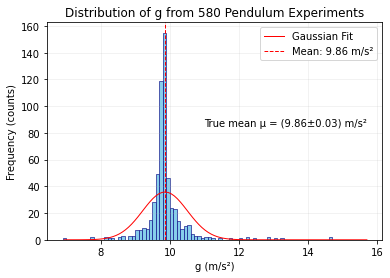

In [6]:
binwidth = 0.1
bins = np.arange(6.9, 15.7 + binwidth, binwidth)
plt.hist(g_values, bins = bins, color='skyblue', edgecolor='navy', linewidth=0.6)

mu = np.mean(g_values)
sigma = np.std(g_values)
x = np.linspace(min(g_values), max(g_values), 100)
gaussian_curve = len(g_values) * binwidth * (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
plt.plot(x, gaussian_curve, color='red', linewidth=1, label = "Gaussian Fit")

plt.axvline(mu, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mu:.2f} m/s²')

plt.legend()

plt.text(11, 85, f"True mean μ = ({mu:.2f}±{(sigma/len(g_values)**0.5):.2f}) m/s²")

plt.title("Distribution of g from 580 Pendulum Experiments")
plt.xlabel("g (m/s²)")
plt.ylabel("Frequency (counts)")
plt.grid(True, alpha=0.3, linewidth = 0.5)
plt.savefig("g_values.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
np.mean(g_values)

9.847233098845098

In [23]:
np.std(g_values)

0.7517158769890279

In [138]:
len(g_values)

580

In [140]:
max(g_values)

15.7